In [1]:

# what technique i can use as NaN imputer :
# Missing Indicator Technique

# This technique involves creating a new binary column for each feature with missing values,
# indicating whether the value was missing (1) or not (0). This can help the model learn
# patterns related to missingness.


# 18% NaN — same 11 rows (Crop & Variety)
# Crop: (Done)
'''All 11 NaN rows contain "Rice" in Sample_Name — the answer is already there
Every single NaN row: "H3-N 2 Rice", "I1-S 3 Rice", "M3-N 2 Rice" etc. Fill with 'Arroz' 
using df.loc[df['Sample_Name'].str.contains('Rice'), 'Crop'] = 'Arroz'. 
This is 100% accurate — no guessing needed. After this, zero NaN in Crop.'''

# Variety: (add one hot encoder for Variety_Unknown)
'''All 13 Rice rows — variety genuinely unknown
All 13 NaN rows are Rice samples. Unlike Crop, the specific rice variety was not recorded. Use 'Unknown_Rice' — not just 'Unknown' — 
so the model knows which crop type the unknown variety belongs to. This preserves crop context in the label.'''

# variety and Crop many may be make column mix of both and one hot encode 




# Density_Plants_Acre            100.00. remove
# Comments                       97.22   removing this columns  

# density plant hectare db : all values but here NaN is replaced with 0/ doubt: if its like we dont know we may just make another column to flag NaN

# Coordinates_DMS_DD             since all from only one location may not help the model remove 
# 

# Collection date : its either 29 or 30, may not be useful or confused may use it as label or one hot encoding 

# Plot name: 36 unique values, used as one hot/ label accordingly (may add noise or confuse)

#  city country drop of no use same location / if different location then may be useful  

# Density plant hectare or DB column:
"""
Plot P3 (Forrajes): Samples 2 and 5 have a density of 2,000. But samples 37, 39, 40, and 60 in Plot P3 have 0. Decision: We can safely overwrite those 0s with 2,000.

Plot N1-N (Forrajes): Samples 25, 41, and 52 have a density of 65,000. But samples 11, 32, 34, and 48 in the same plot have 0. Decision: Overwrite those 0s with 65,000.

Plot H2-N (FLAR): Sample 64 has 133,000. Sample 23 (H2-N 1) has 0. Decision: Overwrite with 133,000. 
"""

# Doubt: can we put this values?? ask

''''
1. The "Plot Twins" Successfully Fixed (8 Zeros Imputed)

Plot P3: 4 zeros are replaced with 2,000.

Plot H2-N: 1 zero is replaced with 133,000.

Plot N1-N: Here is the trap! There are 4 zeros in this plot. 
However, if you look at the Variety column for sample N1-N 3 Forrajes, it is listed as Suelo Desnudo (Bare Soil). 
You should not replace it with 65,000. 

Therefore, only 3 zeros in this plot get replaced with 65,000.

(Total Imputed = 8)

2. The "Intended Zeros" (14 Zeros Kept)

Rice: 11 samples. Since rice is broadcasted, plant density per hectare doesn't apply. They stay 0 (or NaN depending on your model choice).

Bare Soil: 3 samples (including that sneaky N1-N 3 Forrajes). Because there are no crops, the density is mathematically 0.

(Total Kept = 14)



Plot N3 Forrajes (3 samples)

N3 F 1 Forrajes

N3 F 2 Forrajes

N3 F 3 Forrajes


Plot O4 (2 samples)

O4 1 Forrajes

O4 2 Forrajes


# N3 O4 dont have any data for it to assume
this 5 samples are all forajes, doubt: can i mark them 0??
'''



# irrigation usage and irrigation type both label encode (with flag irrigation_is_rice... will see this as we have other columns for this same classification also)
# Doubt(above label encode or one hot encode ??)
# previous year crop one hot encode as many unique cols are there

# Biodynamic Method: No and NaN (binary encoding 0 and 1 with flag (flag imp for NaN as other crops are also there other than rice and forrajes))
# Doubt: Product_1_type 3 categories (with binary flag for NaN)

# Product_1_2_3 dosage may not be relevant for ML Modeling (due to enteries ask???) *considering NLP approach using BERT

# Product 1_2_3 application date: used as number of days from collection to application date (ask??)


###### 

'\'\n1. The "Plot Twins" Successfully Fixed (8 Zeros Imputed)\n\nPlot P3: 4 zeros are replaced with 2,000.\n\nPlot H2-N: 1 zero is replaced with 133,000.\n\nPlot N1-N: Here is the trap! There are 4 zeros in this plot. \nHowever, if you look at the Variety column for sample N1-N 3 Forrajes, it is listed as Suelo Desnudo (Bare Soil). \nYou should not replace it with 65,000. \n\nTherefore, only 3 zeros in this plot get replaced with 65,000.\n\n(Total Imputed = 8)\n\n2. The "Intended Zeros" (14 Zeros Kept)\n\nRice: 11 samples. Since rice is broadcasted, plant density per hectare doesn\'t apply. They stay 0 (or NaN depending on your model choice).\n\nBare Soil: 3 samples (including that sneaky N1-N 3 Forrajes). Because there are no crops, the density is mathematically 0.\n\n(Total Kept = 14)\n\n\n\nPlot N3 Forrajes (3 samples)\n\nN3 F 1 Forrajes\n\nN3 F 2 Forrajes\n\nN3 F 3 Forrajes\n\n\nPlot O4 (2 samples)\n\nO4 1 Forrajes\n\nO4 2 Forrajes\n\n\n# N3 O4 dont have any data for it to assume\n

In [51]:
import pandas as pd

In [52]:
metadata_df = pd.read_csv("/Users/pawanpahune/AI_Pipeline_Metagenomics/preprocessed_V1/metadata_df_imputed.csv")

In [53]:
df = metadata_df.copy()

In [54]:
import pandas as pd



# 0. Drop the annoying 'Unnamed: 0' column if it accidentally got saved
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# =======================================================
# 1. FIX THE DENSITY "PLOT TWINS" (Safeguarding Bare Soil)
# =======================================================
# Identify bare soil so we don't accidentally give it plants!
is_bare_soil = df['Variety'].str.lower().str.contains('suelo desnudo', na=False)

# Plot P3 -> 2000
mask_p3 = (df['Plot_Name'] == 'P3') & (df['Density_Plants_Hectare'] == 0) & (~is_bare_soil)
df.loc[mask_p3, 'Density_Plants_Hectare'] = 2000

# Plot H2-N -> 133,000
mask_h2n = (df['Plot_Name'] == 'H2-N') & (df['Density_Plants_Hectare'] == 0) & (~is_bare_soil)
df.loc[mask_h2n, 'Density_Plants_Hectare'] = 133000

# Plot N1-N -> 65,000
mask_n1n = (df['Plot_Name'] == 'N1-N') & (df['Density_Plants_Hectare'] == 0) & (~is_bare_soil)
df.loc[mask_n1n, 'Density_Plants_Hectare'] = 65000

# =======================================================
# 2. FIX THE SOIL TYPE FOR S1-S (CIMMYT)
# =======================================================
# Overwrite 'Unknown' or NaN with 'Franco' for these specific plots
df.loc[df['Plot_Name'] == 'S1-S', 'Soil_Type'] = 'Franco'

# =======================================================
# 3. CONVERT APPLICATION DATES TO "DAYS SINCE APPLIED"
# =======================================================
# Make sure the main collection date is recognized as a time object
df['Collection_Date'] = pd.to_datetime(df['Collection_Date'])

# Loop through all 3 product columns
for i in [1, 2, 3]:
    date_col = f'Product_{i}_Application_Date'
    
    # Convert the product application date to a time object
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    
    # Calculate "Days Ago" (Collection Date minus Application Date)
    days_ago = (df['Collection_Date'] - df[date_col]).dt.days
    
    # Replace the date string with the numeric days, filling NaNs with -1
    df[date_col] = days_ago.fillna(-1).astype(int)


# -------------------------------------------------------
# VERIFICATION PRINTS
# -------------------------------------------------------
print("✅ Density Fix Check (P3, H2-N, N1-N):")
print(df[df['Plot_Name'].isin(['P3', 'H2-N', 'N1-N'])][['Plot_Name', 'Density_Plants_Hectare', 'Variety']].head(7))

print("\n✅ Soil Type Check (S1-S):")
print(df[df['Plot_Name'] == 'S1-S'][['Plot_Name', 'Sample_Name', 'Soil_Type']])

print("\n✅ Dates Converted to Days (Showing first 5 rows):")
print(df[['Product_1_Application_Date', 'Product_2_Application_Date', 'Product_3_Application_Date']].head())

print(f"\n✅ Index Check: The index is now set to -> '{df.index.name}'")

# Overwrite your cleaned dataframe with this finalized version
metadata_df_cleaned = df



✅ Density Fix Check (P3, H2-N, N1-N):
   Plot_Name  Density_Plants_Hectare  \
2         P3                  2000.0   
5         P3                  2000.0   
6       N1-N                 10000.0   
11      N1-N                 65000.0   
23      H2-N                133000.0   
25      N1-N                 65000.0   
27      N1-N                 10000.0   

                                              Variety  
2   Brachiaria brizantha CIAT 26110 + Leucaena div...  
5   Brachiaria brizantha CIAT 26110 + Leucaena div...  
6                                Multiples variedades  
11           Urochloa humidicola cv. Tully (CIAT 679)  
23                                  Crotalaria Juncea  
25                      Maíz biofortificado (SGBIOH2)  
27                               Multiples variedades  

✅ Soil Type Check (S1-S):
   Plot_Name    Sample_Name Soil_Type
48      S1-S  S1-S 1 CIMMYT    Franco
54      S1-S  S1-S 2 CIMMYT    Franco

✅ Dates Converted to Days (Showing first 5 rows):
 

In [56]:
df_v2 = metadata_df_cleaned.copy()

In [57]:
df_v2

,Code,Sample_Name,Collection_Date,Plot_Name,Crop,Variety,Density_Plants_Hectare,Planting_Year,Previous_Year_Crop,Irrigation_Usage,...,Product_2_Application_Date,Product_3_Type,Product_3_Name,Product_3_Application_Date,sample_simple,Biodynamic_Methods_Flag,Density_Plants_Hectare_Flag,Product_1_type_Flag,Product_2_type_Flag,Product_3_type_Flag
0,AZM03Y,H3-N 2 Rice,2024-01-30,H3-N,Arroz,Unknown,0.0,-1.0,Unknown,-1,...,-1,-1,Unknown,-1,Rice,1,1,1,1,1
1,AZM03Z,E1 2 Beans,2024-01-30,E1,Frijol,Mas de 100,190000.0,2023.0,Frijol,Regular,...,342,Fertilizante sintético,"Kelatex Boro, Mg, Zintrac, Cabtrac, 0-32-43",333,Beans,0,0,0,0,0
2,AZM040,P3 5 Forrajes,2024-01-29,P3,Forrajes,Brachiaria brizantha CIAT 26110 + Leucaena div...,2000.0,-1.0,Unknown,-1,...,-1,-1,Unknown,-1,Forrajes,1,0,1,1,1
3,AZM041,L1-N 1 Beans,2024-01-29,L1-N,Frijol,Mas de 100,190000.0,2024.0,Frijol,Regular,...,-8,Fertilizante sintético,"Boro, Kelatex Mg y Zinc, Fulviplex, 0-32-43",-16,Beans,0,0,0,0,0
4,AZM042,I1-S 3 Rice,2024-01-30,I1-S,Arroz,Unknown,0.0,-1.0,Unknown,-1,...,-1,-1,Unknown,-1,Rice,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,AZM05T,P1-S 1 Cassava,2024-01-30,P1-S,"Yuca, Mandioca, Tapioca",Multiples variedades,10000.0,2023.0,Descanso,Regular,...,-1,-1,Unknown,-1,Cassava,0,0,0,1,1
66,AZM05U,I2-S 1 Cassava,2024-01-30,I2-S,"Yuca, Mandioca, Tapioca",Multiples variedades,10000.0,2023.0,"Yuca, Mandioca, Tapioca",Semi-regular,...,71,-1,Unknown,-1,Cassava,0,0,0,0,1
67,AZM05V,H3-N 1 Rice,2024-01-30,H3-N,Arroz,Unknown,0.0,-1.0,Unknown,-1,...,-1,-1,Unknown,-1,Rice,1,1,1,1,1
68,AZM05W,H3-Bajo 1 Rice,2024-01-30,H3-Bajo,Arroz,Unknown,0.0,-1.0,Unknown,-1,...,-1,-1,Unknown,-1,Rice,1,1,1,1,1


In [58]:

col = df.columns.tolist()

In [59]:
import pandas as pd

col = df.columns.tolist()

 # Just to be safe, we work on a copy of the cleaned DataFrame for this analysis

# The list of columns you mentioned
target_columns = col

print("=== Unique Values, Counts, and Percentages (INCLUDING NaN) ===\n")

# Loop through each column to generate the summary
for col in target_columns:
    if col in metadata_df.columns:
        print(f"📌 Column: {col}")
        
        # Calculate the raw count of each unique value, INCLUDING NaNs
        counts = metadata_df[col].value_counts(dropna=False)
        
        # Calculate the percentage of each unique value, INCLUDING NaNs
        percentages = (metadata_df[col].value_counts(normalize=True, dropna=False) * 100).round(2)
        
        # Fill actual NaN values with the text '<NaN>' so it prints clearly in the table
        display_index = counts.index.fillna('<NaN>')
        
        # Combine both into a clean DataFrame for display
        summary_df = pd.DataFrame({
            'Unique Value': display_index,
            'Count': counts.values,
            'Percentage (%)': percentages.values
        })
        
        # Print the mini-table without the index numbers
        print(summary_df.to_string(index=False))
        print("-" * 65 + "\n")
    else:
        print(f"⚠️ Warning: Column '{col}' not found. Please check the spelling.\n")

=== Unique Values, Counts, and Percentages (INCLUDING NaN) ===

📌 Column: Code
Unique Value  Count  Percentage (%)
      AZM03Y      1            1.43
      AZM057      1            1.43
      AZM05E      1            1.43
      AZM05C      1            1.43
      AZM05B      1            1.43
      AZM05A      1            1.43
      AZM059      1            1.43
      AZM058      1            1.43
      AZM056      1            1.43
      AZM05G      1            1.43
      AZM055      1            1.43
      AZM054      1            1.43
      AZM053      1            1.43
      AZM052      1            1.43
      AZM051      1            1.43
      AZM04Z      1            1.43
      AZM05F      1            1.43
      AZM05H      1            1.43
      AZM03Z      1            1.43
      AZM05Q      1            1.43
      AZM05W      1            1.43
      AZM05V      1            1.43
      AZM05U      1            1.43
      AZM05T      1            1.43
      AZM05S      1  

In [10]:
# product 1 : Unk, Kelatex_Boro, Mg, Zintrac, Cabtrac, 18-45-0, Bortrac, KCL, 15-15-15, sul-amo, DAP, sul-zinc, sul-hierro, sul-magno, 10-30-10, 

In [60]:
import pandas as pd

df = df_v2.copy()

date_columns = [
    'Product_1_Application_Date', 
    'Product_2_Application_Date', 
    'Product_3_Application_Date'
]

print("=== CONVERTING DATES & FIXING CHRONOLOGICAL LEAKS ===")

# 1. Ensure the main Collection Date is a valid Time object
df['Collection_Date'] = pd.to_datetime(df['Collection_Date'], errors='coerce')

for col in date_columns:
    # A. Convert the product application date to a Time object (turns bad text into NaNs)
    df[col] = pd.to_datetime(df[col], errors='coerce')
    
    # B. Calculate "Days Ago" (This turns the dates into pure numbers!)
    days_ago = (df['Collection_Date'] - df[col]).dt.days
    
    # C. Fill any missing data with -1 and force the entire column to be integers
    df[col] = days_ago.fillna(-1).astype(int)
    
    # D. NOW we can safely check for future applications because they are math numbers!
    future_applications = (df[col] < -1).sum()
    
    if future_applications > 0:
        print(f"Fixing {future_applications} future applications in {col}...")
        
        # Overwrite any value less than -1 with -1
        df.loc[df[col] < -1, col] = -1

print("\n✅ Success! All dates are now integers, and future leaks are fixed.")

=== CONVERTING DATES & FIXING CHRONOLOGICAL LEAKS ===

✅ Success! All dates are now integers, and future leaks are fixed.


In [61]:
import pandas as pd
import re


# =========================================================
# STEP 1: THE EXHAUSTIVE AGRONOMIC DICTIONARY
# (Every unique item from your P1, P2, and P3 lists is mapped here)
# =========================================================

agronomic_mapping = {
    # Notice we removed the standalone 'amonio' here to protect against the herbicide!
    'Total_N_Applied': ['urea', 'dap', '18-45-0', '15-15-15', '10-30-10', 'npk', 'sulfato de amonio', 'sulfato amonio'],
    'Total_P_Applied': ['dap', '18-45-0', '15-15-15', '10-30-10', 'npk', '0-32-43', '0-39-52', 'agrimins'],
    'Total_K_Applied': ['kcl', '15-15-15', '10-30-10', 'npk', '0-32-43', '0-39-52', 'agrimins'],
    'Total_Zinc_Applied': ['zinc', 'zintrac', 'agrimins'],
    'Total_Boron_Applied': ['boro', 'bortrac', 'borax', 'cabtrac', 'agrimins'],
    'Total_Iron_Applied': ['hierro', 'agrimins'],
    'Total_Manganese_Applied': ['manganeso', 'agrimins'],
    'Total_Magnesium_Applied': ['mg', 'agrimins'], 
    'Total_Calcium_Applied': ['cabtrac', 'agrimins'],
    'Total_Sulfur_Applied': ['sulfato', 'agrimins'], 
    'Total_Herbicides_Applied': ['diuron', 'ametrina', 'tordon', 'linuron', 'glifosato', 'glufosinato de amonio'],
    'Total_Organic_Acids_Applied': ['fulviplex'],
    'Total_Micronutrients_Other': ['menores']
}

# =========================================================
# STEP 2: FLATTEN THE TIMELINE INTO A "COCKTAIL"
# =========================================================
# Combine all 3 products into one massive string per farm and make it lowercase
df['All_Products'] = (
    df['Product_1_Name'].fillna('') + "," + 
    df['Product_2_Name'].fillna('') + "," + 
    df['Product_3_Name'].fillna('')
).str.lower()

# =========================================================
# STEP 3: BULLETPROOF REGEX COUNTING
# =========================================================
print("=== EXTRACTING BIOLOGICAL FEATURES ===")

# Initialize columns
for new_col in agronomic_mapping.keys():
    df[new_col] = 0

for idx, row in df.iterrows():
    combined_text = row['All_Products']
    
    # Skip if farm applied absolutely nothing
    if combined_text == ',,':
        continue
        
    for new_col, keywords in agronomic_mapping.items():
        count = 0
        for word in keywords:
            # \b creates a "word boundary". It ensures exact matching.
            # It prevents 'mg' from matching inside 'manganeso'
            pattern = r'\b' + re.escape(word) + r'\b'
            matches = len(re.findall(pattern, combined_text))
            count += matches
            
        df.at[idx, new_col] = count

# =========================================================
# STEP 4: CLEAN UP NOISY COLUMNS
# =========================================================
# Drop the raw text columns so XGBoost only sees pure math
cols_to_drop = [
    'Product_1_Name', 'Product_2_Name', 'Product_3_Name', 'All_Products'
]
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# Verify the magic!
print("Success! Your features are ready. Let's look at a complex one:")
complex_rows = df[df['Total_Herbicides_Applied'] > 0]
print(complex_rows[['Sample_Name', 'Total_Herbicides_Applied', 'Total_Sulfur_Applied', 'Total_N_Applied']].head())



=== EXTRACTING BIOLOGICAL FEATURES ===
Success! Your features are ready. Let's look at a complex one:
            Sample_Name  Total_Herbicides_Applied  Total_Sulfur_Applied  \
18          Q2-S 1 Caña                         3                     0   
44  M4-S 1 Michael Maiz                         3                     1   
60            F2 1 Caña                         3                     0   

    Total_N_Applied  
18                1  
44                0  
60                1  


In [13]:
''' #import pandas as pd


# ==========================================
# 1. SET INDEX & DROP TEXT/REDUNDANT COLUMNS
# ==========================================
#df.set_index('Code', inplace=True)

# We include 'sample_simple' here so it is safely removed and doesn't crash XGBoost
cols_to_drop = ['Sample_Name', 'Collection_Date', 'Plot_Name', 'Planting_Year', 'sample_simple']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

# ==========================================
# 2. CROP VARIETY FUSION & INVISIBLE SPACE CLEANUP
# ==========================================
# Strip trailing spaces from text columns before fusing so we don't get messy column names!
df['Crop'] = df['Crop'].astype(str).str.strip()
df['Variety'] = df['Variety'].astype(str).str.strip()

# Combine them with an underscore
df['Crop_Variety'] = df['Crop'] + "_" + df['Variety']

# Drop the original separated columns
df.drop(columns=['Crop', 'Variety'], inplace=True)

# ==========================================
# 3. BINARY MAPPINGS (Organic & Biodynamic)
# ==========================================
binary_map = {'No': 0, 'Si': 1, '0': -1, 0: -1, '-1': -1, -1: -1}

df['Organic_Practices'] = df['Organic_Practices'].map(binary_map).fillna(-1).astype(int)
df['Biodynamic_Methods'] = df['Biodynamic_Methods'].map(binary_map).fillna(-1).astype(int)

# ==========================================
# 4. ORDINAL ENCODING: IRRIGATION USAGE
# ==========================================
# Strip spaces just in case, then map
df['Irrigation_Usage'] = df['Irrigation_Usage'].astype(str).str.strip()

usage_map = {
    '-1': -1,
    '-1.0': -1,
    'Descanso': 0,      
    'Semi-regular': 1,
    'Regular': 2
}
df['Irrigation_Usage'] = df['Irrigation_Usage'].map(usage_map).fillna(-1).astype(int)

# ==========================================
# 5. ONE-HOT ENCODING (Fixed & Stripped)
# ==========================================
# List of columns to One-Hot Encode (sample_simple is intentionally NOT here)
one_hot_columns = [
    'Crop_Variety', 
    'Previous_Year_Crop', 
    'Irrigation_Type', 
    'Soil_Type',
    'Product_1_Type', 
    'Product_2_Type', 
    'Product_3_Type'
]

# Ensure we only encode columns that are actually present
one_hot_columns = [c for c in one_hot_columns if c in df.columns]

# Strip invisible spaces from these columns before encoding to fix the warning!
for col in one_hot_columns:
    df[col] = df[col].astype(str).str.strip()

# Apply get_dummies with dtype=int to force 0s and 1s (Fixes True/False warnings)
df = pd.get_dummies(df, columns=one_hot_columns, drop_first=False, dtype=int)

# ==========================================
# VERIFICATION & SAVE
# ==========================================
print(f"✅ Final Dataset Shape: {df.shape}")
print(f"✅ Text columns remaining: {sum(df.dtypes == 'object')} (Should be 0)")
'''


' #import pandas as pd\n\n\n# ==========================================\n# 1. SET INDEX & DROP TEXT/REDUNDANT COLUMNS\n# ==========================================\n#df.set_index(\'Code\', inplace=True)\n\n# We include \'sample_simple\' here so it is safely removed and doesn\'t crash XGBoost\ncols_to_drop = [\'Sample_Name\', \'Collection_Date\', \'Plot_Name\', \'Planting_Year\', \'sample_simple\']\ndf.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)\n\n# ==========================================\n# 2. CROP VARIETY FUSION & INVISIBLE SPACE CLEANUP\n# ==========================================\n# Strip trailing spaces from text columns before fusing so we don\'t get messy column names!\ndf[\'Crop\'] = df[\'Crop\'].astype(str).str.strip()\ndf[\'Variety\'] = df[\'Variety\'].astype(str).str.strip()\n\n# Combine them with an underscore\ndf[\'Crop_Variety\'] = df[\'Crop\'] + "_" + df[\'Variety\']\n\n# Drop the original separated columns\ndf.drop(columns=[\'Crop\', \'

In [62]:
import pandas as pd

# ==========================================
# 1. SET INDEX & DROP TEXT/REDUNDANT COLUMNS


cols_to_drop = ['Sample_Name', 'Collection_Date', 'Plot_Name', 'Planting_Year', 'sample_simple']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True, errors='ignore')

# ==========================================
# 2. MULTI-CLASS TARGET ENCODING (The Prediction Goal)
# ==========================================
# Clean the text
df['Crop'] = df['Crop'].astype(str).str.strip()

# XGBoost needs the target to be numerical (0, 1, 2...). 
# We use pandas Categorical to safely encode this.
df['Crop'] = pd.Categorical(df['Crop'])
df['Target_Crop'] = df['Crop'].cat.codes # This creates your 0, 1, 2 column

# Save the dictionary so you know what the numbers mean later!
crop_mapping = dict(enumerate(df['Crop'].cat.categories))
print(f"🎯 TARGET MAPPING SAVED: {crop_mapping}")

# ==========================================
# 3. PREVENT DATA LEAKAGE (CRITICAL!)
# ==========================================
# We MUST drop the original 'Crop' text and the 'Variety' column so the model doesn't cheat.
df.drop(columns=['Crop', 'Variety'], inplace=True, errors='ignore')

# ==========================================
# 4. BINARY & ORDINAL MAPPINGS
# ==========================================
binary_map = {'No': 0, 'Si': 1, '0': -1, 0: -1, '-1': -1, -1: -1}
df['Organic_Practices'] = df['Organic_Practices'].map(binary_map).fillna(-1).astype(int)
df['Biodynamic_Methods'] = df['Biodynamic_Methods'].map(binary_map).fillna(-1).astype(int)

df['Irrigation_Usage'] = df['Irrigation_Usage'].astype(str).str.strip()
usage_map = {'-1': -1, '-1.0': -1, 'Descanso': 0, 'Semi-regular': 1, 'Regular': 2}
df['Irrigation_Usage'] = df['Irrigation_Usage'].map(usage_map).fillna(-1).astype(int)

# ==========================================
# 5. SPARSITY FIX: FREQUENCY BINNING 
# ==========================================
# This function groups any rare categories into "Other" to prevent massive, empty One-Hot columns
def group_rare_categories(series, threshold=4, other_label='Other_Rare'):
    counts = series.value_counts()
    rare_items = counts[counts < threshold].index
    return series.replace(rare_items, other_label)

# Apply to Previous_Year_Crop to fix its sparsity!
df['Previous_Year_Crop'] = df['Previous_Year_Crop'].astype(str).str.strip()
df['Previous_Year_Crop'] = group_rare_categories(df['Previous_Year_Crop'], threshold=4)

# ==========================================
# 6. ONE-HOT ENCODING
# ==========================================
one_hot_columns = [
    'Previous_Year_Crop', 
    'Irrigation_Type', 
    'Soil_Type',
    'Product_1_Type', 
    'Product_2_Type', 
    'Product_3_Type'
]

one_hot_columns = [c for c in one_hot_columns if c in df.columns]

# Strip spaces
for col in one_hot_columns:
    df[col] = df[col].astype(str).str.strip()

# Create the final dummy matrix
df = pd.get_dummies(df, columns=one_hot_columns, drop_first=False, dtype=int)

# ==========================================
# VERIFICATION & SAVE
# ==========================================
print(f"✅ Final Dataset Shape: {df.shape}")
print(f"✅ Your Target Column to Predict is: 'Target_Crop'")



🎯 TARGET MAPPING SAVED: {0: 'Arroz', 1: 'Caña de azúcar', 2: 'Clitoria', 3: 'Crotalaria', 4: 'Forrajes', 5: 'Frijol', 6: 'Maíz', 7: 'Suelo Desnudo', 8: 'Yuca, Mandioca, Tapioca'}
✅ Final Dataset Shape: (70, 53)
✅ Your Target Column to Predict is: 'Target_Crop'


In [63]:
df.columns

Index(['Code', 'Density_Plants_Hectare', 'Irrigation_Usage',
       'Organic_Practices', 'Biodynamic_Methods', 'Product_1_Application_Date',
       'Product_2_Application_Date', 'Product_3_Application_Date',
       'Biodynamic_Methods_Flag', 'Density_Plants_Hectare_Flag',
       'Product_1_type_Flag', 'Product_2_type_Flag', 'Product_3_type_Flag',
       'Total_N_Applied', 'Total_P_Applied', 'Total_K_Applied',
       'Total_Zinc_Applied', 'Total_Boron_Applied', 'Total_Iron_Applied',
       'Total_Manganese_Applied', 'Total_Magnesium_Applied',
       'Total_Calcium_Applied', 'Total_Sulfur_Applied',
       'Total_Herbicides_Applied', 'Total_Organic_Acids_Applied',
       'Total_Micronutrients_Other', 'Target_Crop',
       'Previous_Year_Crop_Caña De Azúcar', 'Previous_Year_Crop_Descanso',
       'Previous_Year_Crop_Frijol', 'Previous_Year_Crop_Other_Rare',
       'Previous_Year_Crop_Unknown',
       'Previous_Year_Crop_Yuca, Mandioca, Tapioca', 'Irrigation_Type_-1',
       'Irrigation_Typ

In [64]:
import pandas as pd

col = df.columns.tolist()

 # Just to be safe, we work on a copy of the cleaned DataFrame for this analysis

# The list of columns you mentioned
target_columns = col

print("=== Unique Values, Counts, and Percentages (INCLUDING NaN) ===\n")

metadata_df = df.copy()

# Loop through each column to generate the summary
for col in target_columns:
    if col in metadata_df.columns:
        print(f"📌 Column: {col}")
        
        # Calculate the raw count of each unique value, INCLUDING NaNs
        counts = metadata_df[col].value_counts(dropna=False)
        
        # Calculate the percentage of each unique value, INCLUDING NaNs
        percentages = (metadata_df[col].value_counts(normalize=True, dropna=False) * 100).round(2)
        
        # Fill actual NaN values with the text '<NaN>' so it prints clearly in the table
        display_index = counts.index.fillna('<NaN>')
        
        # Combine both into a clean DataFrame for display
        summary_df = pd.DataFrame({
            'Unique Value': display_index,
            'Count': counts.values,
            'Percentage (%)': percentages.values
        })
        
        # Print the mini-table without the index numbers
        print(summary_df.to_string(index=False))
        print("-" * 65 + "\n")
    else:
        print(f"⚠️ Warning: Column '{col}' not found. Please check the spelling.\n")

=== Unique Values, Counts, and Percentages (INCLUDING NaN) ===

📌 Column: Code
Unique Value  Count  Percentage (%)
      AZM03Y      1            1.43
      AZM057      1            1.43
      AZM05E      1            1.43
      AZM05C      1            1.43
      AZM05B      1            1.43
      AZM05A      1            1.43
      AZM059      1            1.43
      AZM058      1            1.43
      AZM056      1            1.43
      AZM05G      1            1.43
      AZM055      1            1.43
      AZM054      1            1.43
      AZM053      1            1.43
      AZM052      1            1.43
      AZM051      1            1.43
      AZM04Z      1            1.43
      AZM05F      1            1.43
      AZM05H      1            1.43
      AZM03Z      1            1.43
      AZM05Q      1            1.43
      AZM05W      1            1.43
      AZM05V      1            1.43
      AZM05U      1            1.43
      AZM05T      1            1.43
      AZM05S      1  

In [17]:
''' 0 ➡️ Arroz (Rice)

1 ➡️ Caña de azúcar (Sugarcane)

2 ➡️ Clitoria

3 ➡️ Crotalaria

4 ➡️ Forrajes (Forages)

5 ➡️ Frijol (Beans)

6 ➡️ Maíz (Maize / Corn)

7 ➡️ Suelo Desnudo (Bare Soil)

8 ➡️ Yuca, Mandioca, Tapioca (Cassava) '''

' 0 ➡️ Arroz (Rice)\n\n1 ➡️ Caña de azúcar (Sugarcane)\n\n2 ➡️ Clitoria\n\n3 ➡️ Crotalaria\n\n4 ➡️ Forrajes (Forages)\n\n5 ➡️ Frijol (Beans)\n\n6 ➡️ Maíz (Maize / Corn)\n\n7 ➡️ Suelo Desnudo (Bare Soil)\n\n8 ➡️ Yuca, Mandioca, Tapioca (Cassava) '

In [18]:
# df.to_csv("Preprocessed_Cleaned_Metadata.csv", index=False)

In [66]:
import pandas as pd

# 1. Load the dataset


# Clean up the index column if it exists
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# ==========================================
# TARGET GROUPING (4-Class Agronomic Model)
# ==========================================
# Current classes: 
# 0: Arroz, 1: Caña, 2: Clitoria, 3: Crotalaria, 4: Forrajes, 
# 5: Frijol, 6: Maíz, 7: Suelo Desnudo, 8: Yuca

# 1. Drop Bare Soil (Class 7) since it's a control group with only 3 samples
df = df[df['Target_Crop'] != 7].copy()

# 2. Define the biological grouping map
grouping_map = {
    0: 0, # Grasses (Arroz)
    1: 0, # Grasses (Caña)
    6: 0, # Grasses (Maíz)
    
    8: 1, # Root Crop (Yuca)
    
    4: 2, # Pasture (Forrajes)
    
    2: 3, # Legumes (Clitoria)
    3: 3, # Legumes (Crotalaria)
    5: 3, # Legumes (Frijol)
}

# 3. Apply Mapping
df['Target_Crop_Grouped'] = df['Target_Crop'].map(grouping_map)

# 4. Drop the old target column
df.drop(columns=['Target_Crop'], inplace=True)

# ==========================================
# VERIFICATION & SAVE
# ==========================================
print("=== NEW 4-CLASS DISTRIBUTION ===")
new_mapping = {
    0: 'Grasses (Rice, Corn, Sugarcane)',
    1: 'Root Crops (Cassava)',
    2: 'Pasture (Forages)',
    3: 'Legumes (Beans, Crotalaria, Clitoria)'
}

counts = df['Target_Crop_Grouped'].value_counts().sort_index()
for idx, count in counts.items():
    print(f"Class {int(idx)} - {new_mapping[idx]}: {count} samples")

# Save the dataset with just the grouped target
df.to_csv("Dataset_XGBoost_Grouped_Only.csv", index=False)
print("\n✅ Dataset saved as: Dataset_XGBoost_Grouped_Only.csv")



=== NEW 4-CLASS DISTRIBUTION ===
Class 0 - Grasses (Rice, Corn, Sugarcane): 21 samples
Class 1 - Root Crops (Cassava): 15 samples
Class 2 - Pasture (Forages): 14 samples
Class 3 - Legumes (Beans, Crotalaria, Clitoria): 17 samples

✅ Dataset saved as: Dataset_XGBoost_Grouped_Only.csv


In [67]:
df

,Code,Density_Plants_Hectare,Irrigation_Usage,Organic_Practices,Biodynamic_Methods,Product_1_Application_Date,Product_2_Application_Date,Product_3_Application_Date,Biodynamic_Methods_Flag,Density_Plants_Hectare_Flag,...,Product_1_Type_-1,Product_1_Type_Fertilizante sintético,Product_1_Type_Otras practicas,Product_2_Type_-1,Product_2_Type_Fertilizante sintético,Product_2_Type_Herbicida,Product_3_Type_-1,Product_3_Type_Fertilizante sintético,Product_3_Type_Herbicida,Target_Crop_Grouped
0,AZM03Y,0.0,-1,-1,-1,19752,19752,19752,1,1,...,1,0,0,1,0,0,1,0,0,0
1,AZM03Z,190000.0,2,1,0,19751,19751,19751,0,0,...,0,1,0,0,1,0,0,1,0,3
2,AZM040,2000.0,-1,-1,-1,19751,19751,19751,1,0,...,1,0,0,1,0,0,1,0,0,2
3,AZM041,190000.0,2,0,0,19751,19751,19751,0,0,...,0,1,0,0,1,0,0,1,0,3
4,AZM042,0.0,-1,-1,-1,19752,19752,19752,1,1,...,1,0,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,AZM05T,10000.0,2,0,0,19751,19752,19752,0,0,...,0,1,0,1,0,0,1,0,0,1
66,AZM05U,10000.0,1,0,0,19751,19751,19752,0,0,...,0,1,0,0,1,0,1,0,0,1
67,AZM05V,0.0,-1,-1,-1,19752,19752,19752,1,1,...,1,0,0,1,0,0,1,0,0,0
68,AZM05W,0.0,-1,-1,-1,19752,19752,19752,1,1,...,1,0,0,1,0,0,1,0,0,0


In [68]:
import pandas as pd

col = df.columns.tolist()

 # Just to be safe, we work on a copy of the cleaned DataFrame for this analysis

# The list of columns you mentioned
target_columns = col

print("=== Unique Values, Counts, and Percentages (INCLUDING NaN) ===\n")

metadata_df = df.copy()

# Loop through each column to generate the summary
for col in target_columns:
    if col in metadata_df.columns:
        print(f"📌 Column: {col}")
        
        # Calculate the raw count of each unique value, INCLUDING NaNs
        counts = metadata_df[col].value_counts(dropna=False)
        
        # Calculate the percentage of each unique value, INCLUDING NaNs
        percentages = (metadata_df[col].value_counts(normalize=True, dropna=False) * 100).round(2)
        
        # Fill actual NaN values with the text '<NaN>' so it prints clearly in the table
        display_index = counts.index.fillna('<NaN>')
        
        # Combine both into a clean DataFrame for display
        summary_df = pd.DataFrame({
            'Unique Value': display_index,
            'Count': counts.values,
            'Percentage (%)': percentages.values
        })
        
        # Print the mini-table without the index numbers
        print(summary_df.to_string(index=False))
        print("-" * 65 + "\n")
    else:
        print(f"⚠️ Warning: Column '{col}' not found. Please check the spelling.\n")

=== Unique Values, Counts, and Percentages (INCLUDING NaN) ===

📌 Column: Code
Unique Value  Count  Percentage (%)
      AZM03Y      1            1.49
      AZM05H      1            1.49
      AZM052      1            1.49
      AZM053      1            1.49
      AZM054      1            1.49
      AZM055      1            1.49
      AZM056      1            1.49
      AZM057      1            1.49
      AZM058      1            1.49
      AZM059      1            1.49
      AZM05A      1            1.49
      AZM05B      1            1.49
      AZM05C      1            1.49
      AZM05E      1            1.49
      AZM05F      1            1.49
      AZM05G      1            1.49
      AZM05I      1            1.49
      AZM04Z      1            1.49
      AZM05J      1            1.49
      AZM05K      1            1.49
      AZM05L      1            1.49
      AZM05M      1            1.49
      AZM05N      1            1.49
      AZM05O      1            1.49
      AZM05P      1  

In [ ]:
'''
0: 'Grasses (Rice, Corn, Sugarcane)',
    
1: 'Root Crops (Cassava)',

2: 'Pasture (Forages)',

3: 'Legumes (Beans, Crotalaria, Clitoria)

'''

In [69]:

# ==========================================
# 1. DROP SPECIFIC REQUESTED COLUMNS
# ==========================================
cols_to_drop = [
    'Density_Plants_Hectare', 
    'Biodynamic_Methods_Flag',
    'Density_Plants_Hectare_Flag',
    'Product_1_Application_Date',
    'Product_2_Application_Date',
    'Product_3_Application_Date',
    'Product_1_Type_-1',
    'Product_2_Type_-1',
    'Product_3_Type_-1',
    'Irrigation_Type_-1',
    'Previous_Year_Crop_Unknown',
    'Product_1_type_Flag',  # Just in case these are still lingering!
    'Product_2_type_Flag',
    'Product_3_type_Flag'
]

# Safely drop only the ones that exist in the dataframe
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True, errors='ignore')

# ==========================================
# 2. TIGHTEN IRRIGATION USAGE SCALE
# ==========================================
# Current: -1 (Unknown), 1 (Semi), 2 (Regular)
# New:     -1 (Unknown), 0 (Semi), 1 (Regular)
if 'Irrigation_Usage' in df.columns:
    usage_remapper = {-1: -1, 1: 0, 2: 1}
    df['Irrigation_Usage'] = df['Irrigation_Usage'].map(usage_remapper).fillna(-1).astype(int)

# ==========================================
# 3. AUTOMATED NEAR-ZERO VARIANCE (SPARSITY) FILTER
# ==========================================
# We will dynamically find any column that is >95% zeros and drop it.
# This perfectly handles your Herbicides, Organic Acids, and rare Soil/Irrigation types!

threshold = 0.9  
sparse_cols_to_drop = []

for col in df.columns:
    # We don't want to accidentally drop our Target column!
    if col == 'Target_Crop_Grouped':
        continue
        
    # Check what percentage of the column is strictly '0'
    zero_ratio = (df[col] == 0).mean()
    
    if zero_ratio > threshold:
        sparse_cols_to_drop.append(col)

print(f"\n🚨 SPARSITY FILTER TRIGGERED:")
print(f"Dropping {len(sparse_cols_to_drop)} columns that are >95% empty/zeros:")
for c in sparse_cols_to_drop:
    print(f" - {c}")

df.drop(columns=sparse_cols_to_drop, inplace=True)

# ==========================================
# VERIFICATION & SAVE
# ==========================================
print(f"\n✅ Final Optimized Shape: {df.shape}")
print("Your dataset is now free of noise, leakage, and dummy traps.")

# Save the Ultimate, perfectly optimized dataset



🚨 SPARSITY FILTER TRIGGERED:
Dropping 14 columns that are >95% empty/zeros:
 - Total_Herbicides_Applied
 - Total_Organic_Acids_Applied
 - Total_Micronutrients_Other
 - Previous_Year_Crop_Caña De Azúcar
 - Previous_Year_Crop_Other_Rare
 - Previous_Year_Crop_Yuca, Mandioca, Tapioca
 - Irrigation_Type_Aspersor
 - Irrigation_Type_Otro
 - Soil_Type_Arcillo-limoso
 - Soil_Type_Franco
 - Soil_Type_Franco-arcillo-arenoso
 - Product_1_Type_Otras practicas
 - Product_2_Type_Herbicida
 - Product_3_Type_Herbicida

✅ Final Optimized Shape: (67, 25)
Your dataset is now free of noise, leakage, and dummy traps.


In [70]:
df

,Code,Irrigation_Usage,Organic_Practices,Biodynamic_Methods,Total_N_Applied,Total_P_Applied,Total_K_Applied,Total_Zinc_Applied,Total_Boron_Applied,Total_Iron_Applied,...,Previous_Year_Crop_Frijol,Irrigation_Type_Aspersor-Superficie,Irrigation_Type_Superficie,Soil_Type_Arcilloso,Soil_Type_Franco-arcilloso,Soil_Type_Unknown,Product_1_Type_Fertilizante sintético,Product_2_Type_Fertilizante sintético,Product_3_Type_Fertilizante sintético,Target_Crop_Grouped
0,AZM03Y,-1,-1,-1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,AZM03Z,1,1,0,1,3,2,3,6,0,...,1,0,1,1,0,0,1,1,1,3
2,AZM040,-1,-1,-1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,2
3,AZM041,1,0,0,1,3,2,3,5,0,...,1,0,1,1,0,0,1,1,1,3
4,AZM042,-1,-1,-1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,AZM05T,1,0,0,3,1,1,1,0,1,...,0,1,0,0,0,0,1,0,0,1
66,AZM05U,0,0,0,5,1,0,2,2,2,...,0,0,1,0,1,0,1,1,0,1
67,AZM05V,-1,-1,-1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
68,AZM05W,-1,-1,-1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [71]:
import pandas as pd

col = df.columns.tolist()

 # Just to be safe, we work on a copy of the cleaned DataFrame for this analysis

# The list of columns you mentioned
target_columns = col

print("=== Unique Values, Counts, and Percentages (INCLUDING NaN) ===\n")

metadata_df = df.copy()

# Loop through each column to generate the summary
for col in target_columns:
    if col in metadata_df.columns:
        print(f"📌 Column: {col}")
        
        # Calculate the raw count of each unique value, INCLUDING NaNs
        counts = metadata_df[col].value_counts(dropna=False)
        
        # Calculate the percentage of each unique value, INCLUDING NaNs
        percentages = (metadata_df[col].value_counts(normalize=True, dropna=False) * 100).round(2)
        
        # Fill actual NaN values with the text '<NaN>' so it prints clearly in the table
        display_index = counts.index.fillna('<NaN>')
        
        # Combine both into a clean DataFrame for display
        summary_df = pd.DataFrame({
            'Unique Value': display_index,
            'Count': counts.values,
            'Percentage (%)': percentages.values
        })
        
        # Print the mini-table without the index numbers
        print(summary_df.to_string(index=False))
        print("-" * 65 + "\n")
    else:
        print(f"⚠️ Warning: Column '{col}' not found. Please check the spelling.\n")

=== Unique Values, Counts, and Percentages (INCLUDING NaN) ===

📌 Column: Code
Unique Value  Count  Percentage (%)
      AZM03Y      1            1.49
      AZM05H      1            1.49
      AZM052      1            1.49
      AZM053      1            1.49
      AZM054      1            1.49
      AZM055      1            1.49
      AZM056      1            1.49
      AZM057      1            1.49
      AZM058      1            1.49
      AZM059      1            1.49
      AZM05A      1            1.49
      AZM05B      1            1.49
      AZM05C      1            1.49
      AZM05E      1            1.49
      AZM05F      1            1.49
      AZM05G      1            1.49
      AZM05I      1            1.49
      AZM04Z      1            1.49
      AZM05J      1            1.49
      AZM05K      1            1.49
      AZM05L      1            1.49
      AZM05M      1            1.49
      AZM05N      1            1.49
      AZM05O      1            1.49
      AZM05P      1  

In [72]:
df

,Code,Irrigation_Usage,Organic_Practices,Biodynamic_Methods,Total_N_Applied,Total_P_Applied,Total_K_Applied,Total_Zinc_Applied,Total_Boron_Applied,Total_Iron_Applied,...,Previous_Year_Crop_Frijol,Irrigation_Type_Aspersor-Superficie,Irrigation_Type_Superficie,Soil_Type_Arcilloso,Soil_Type_Franco-arcilloso,Soil_Type_Unknown,Product_1_Type_Fertilizante sintético,Product_2_Type_Fertilizante sintético,Product_3_Type_Fertilizante sintético,Target_Crop_Grouped
0,AZM03Y,-1,-1,-1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,AZM03Z,1,1,0,1,3,2,3,6,0,...,1,0,1,1,0,0,1,1,1,3
2,AZM040,-1,-1,-1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,2
3,AZM041,1,0,0,1,3,2,3,5,0,...,1,0,1,1,0,0,1,1,1,3
4,AZM042,-1,-1,-1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,AZM05T,1,0,0,3,1,1,1,0,1,...,0,1,0,0,0,0,1,0,0,1
66,AZM05U,0,0,0,5,1,0,2,2,2,...,0,0,1,0,1,0,1,1,0,1
67,AZM05V,-1,-1,-1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
68,AZM05W,-1,-1,-1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [73]:
df.to_csv("Metadata-without-taxa-v1.csv", index=False)

In [31]:
pip install lazypredict

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyClassifier

# ==========================================
# 1. LOAD THE FINAL DATASET
# ==========================================
# Use the final dataset we just created


# Ensure the target column is strictly integer (required for classification)
df['Target_Crop_Grouped'] = df['Target_Crop_Grouped'].astype(int)

# ==========================================
# 2. SPLIT FEATURES (X) AND TARGET (y)
# ==========================================
X = df.drop(columns=['Target_Crop_Grouped'])
y = df['Target_Crop_Grouped']

# ==========================================
# 3. BALANCED TRAIN/TEST SPLIT (70% / 30%)
# ==========================================
# stratify=y is the magic parameter. It forces the split to maintain 
# the exact same percentage of each crop in both Train and Test sets!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.5, 
    random_state=42, 
    stratify=y  
)

print(f"📊 Training Data: {X_train.shape[0]} samples")
print(f"🧪 Testing Data:  {X_test.shape[0]} samples\n")

# Verify the Stratification worked
print("=== TRAINING SET DISTRIBUTION ===")
print(y_train.value_counts().sort_index())
print("\n=== TESTING SET DISTRIBUTION ===")
print(y_test.value_counts().sort_index())
print("-" * 50)

# ==========================================
# 4. RUN LAZY PREDICT (MULTI-CLASS)
# ==========================================
print("\n🚀 Running LazyPredict across 30+ Machine Learning Models...")

# Initialize LazyClassifier 
# (It automatically calculates Accuracy, Balanced Accuracy, ROC AUC, and F1-Score)
clf = LazyClassifier(
    verbose=0, 
    ignore_warnings=True, 
    custom_metric=None, 
    predictions=False
)

# Fit all models instantly
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

# ==========================================
# 5. VIEW THE RESULTS
# ==========================================
print("\n🏆 LEADERBOARD: TOP PERFORMING MODELS")
# LazyPredict outputs Accuracy, Balanced Accuracy, and F1 out of the box
print(models.sort_values(by='Accuracy', ascending=False))

📊 Training Data: 46 samples
🧪 Testing Data:  21 samples

=== TRAINING SET DISTRIBUTION ===
Target_Crop_Grouped
0    14
1    10
2    10
3    12
Name: count, dtype: int64

=== TESTING SET DISTRIBUTION ===
Target_Crop_Grouped
0    7
1    5
2    4
3    5
Name: count, dtype: int64
--------------------------------------------------

🚀 Running LazyPredict across 30+ Machine Learning Models...

🏆 LEADERBOARD: TOP PERFORMING MODELS
                               Accuracy  Balanced Accuracy   ROC AUC  \
Model                                                                  
SVC                            0.809524           0.750000       NaN   
SGDClassifier                  0.809524           0.750000       NaN   
CalibratedClassifierCV         0.809524           0.750000  0.937975   
LinearSVC                      0.761905           0.821429       NaN   
CatBoostClassifier             0.761905           0.821429  0.937975   
KNeighborsClassifier           0.761905           0.714286  0.907363 

In [36]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# 1. Load the Final Dataset


print("="*50)
print("🕵️‍♂️ DATA LEAKAGE 'LIE DETECTOR' TEST")
print("="*50)

# ==========================================
# TEST 1: THE DUPLICATE ROW CHECK
# ==========================================
# If duplicate rows exist, they leak between Train and Test splits!
duplicate_count = df.duplicated().sum()
print(f"\n[TEST 1] Duplicate Rows: {duplicate_count}")
if duplicate_count > 0:
    print(f"🚨 DANGER: You have {duplicate_count} identical rows! You MUST drop them using df.drop_duplicates()")
else:
    print("✅ PASS: No duplicate rows detected. Train/Test split will be pure.")

# ==========================================
# TEST 2: THE "SILVER BULLET" FEATURE CHECK
# ==========================================
# We train a Random Forest and see if ONE feature is doing all the work.
X = df.drop(columns=['Target_Crop_Grouped'])
y = df['Target_Crop_Grouped']

rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=4)
rf.fit(X, y)

importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

top_feature = importances.iloc[0]

print(f"\n[TEST 2] Feature Importance Concentration:")
print(f"Top Feature: {top_feature['Feature']} ({top_feature['Importance']:.2%} of predictive power)")

if top_feature['Importance'] > 0.40:
    print("🚨 WARNING: One single feature is doing more than 40% of the work.")
    print("This feature might be a 'cheat code' (Target Leakage) rather than actual biology.")
else:
    print("✅ PASS: The model is using a healthy mix of multiple features to make decisions.")

print("\nTop 5 Features driving your model:")
print(importances.head(5).to_string(index=False))

# ==========================================
# TEST 3: THE PERFECT PROXY CHECK (Crosstab)
# ==========================================
# We check if any categorical/binary feature PERFECTLY identifies a crop.
print("\n[TEST 3] Perfect Proxy Check:")
proxy_found = False

for col in X.columns:
    # Only check binary or low-unique-value categorical columns
    if X[col].nunique() <= 3:
        crosstab = pd.crosstab(X[col], y)
        # Check if any cell contains the ENTIRE count for a specific target class
        for target_class in crosstab.columns:
            class_total = crosstab[target_class].sum()
            # If a single feature value perfectly captures 100% of a class (and >= 5 samples)
            if any((crosstab[target_class] == class_total) & (class_total >= 5)):
                # Also check if it's EXCLUSIVE to that class
                for feature_val in crosstab.index:
                    if crosstab.loc[feature_val, target_class] == class_total and crosstab.loc[feature_val].sum() == class_total:
                        print(f"🚨 LEAKAGE DETECTED: '{col}' = {feature_val} is a PERFECT proxy for Crop Group {target_class}!")
                        proxy_found = True

if not proxy_found:
    print("✅ PASS: No binary feature perfectly gives away the answer.")
print("="*50)

🕵️‍♂️ DATA LEAKAGE 'LIE DETECTOR' TEST

[TEST 1] Duplicate Rows: 39
🚨 DANGER: You have 39 identical rows! You MUST drop them using df.drop_duplicates()

[TEST 2] Feature Importance Concentration:
Top Feature: Total_Sulfur_Applied (13.41% of predictive power)
✅ PASS: The model is using a healthy mix of multiple features to make decisions.

Top 5 Features driving your model:
                  Feature  Importance
     Total_Sulfur_Applied    0.134117
Previous_Year_Crop_Frijol    0.110337
        Soil_Type_Unknown    0.100265
       Biodynamic_Methods    0.099464
        Organic_Practices    0.079832

[TEST 3] Perfect Proxy Check:
✅ PASS: No binary feature perfectly gives away the answer.


In [48]:
import pandas as pd



# 2. Find ALL rows that have a duplicate (keep=False keeps the original AND the copy)
# This allows you to see them side-by-side
duplicates = df[df.duplicated(keep=False)]

# 3. Sort them so identical rows are grouped together
# We sort by all columns to ensure perfect grouping
duplicates_sorted = duplicates.sort_values(by=list(df.columns))

print(f"Total rows involved in duplicates: {len(duplicates_sorted)}")
print("="*50)
print("🔍 INSPECTING DUPLICATE ROWS:")
print("="*50)

# 4. Force Pandas to display ALL rows and columns so nothing is hidden
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Print the duplicates
print(duplicates_sorted)

# Reset Pandas display options back to normal afterwards
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
duplicates_sorted.to_csv("duplicate_rows.csv", index=False)

Total rows involved in duplicates: 49
🔍 INSPECTING DUPLICATE ROWS:
    Irrigation_Usage  Organic_Practices  Biodynamic_Methods  Total_N_Applied  Total_P_Applied  Total_K_Applied  Total_Zinc_Applied  Total_Boron_Applied  Total_Iron_Applied  Total_Manganese_Applied  Total_Magnesium_Applied  Total_Calcium_Applied  Total_Sulfur_Applied  Previous_Year_Crop_Descanso  Previous_Year_Crop_Frijol  Irrigation_Type_Aspersor-Superficie  Irrigation_Type_Superficie  Soil_Type_Arcilloso  Soil_Type_Franco-arcilloso  Soil_Type_Unknown  Product_1_Type_Fertilizante sintético  Product_2_Type_Fertilizante sintético  Product_3_Type_Fertilizante sintético  Target_Crop_Grouped
0                 -1                 -1                  -1                0                0                0                   0                    0                   0                        0                        0                      0                     0                            0                          0                 


=== 🎯 CONFUSION MATRICES FOR TOP 3 MODELS ===

🏆 Model: LinearSVC
[[2 0 5 0]
 [0 5 0 0]
 [0 0 4 0]
 [0 0 0 5]]

🏆 Model: LabelPropagation
[[2 0 5 0]
 [0 5 0 0]
 [0 0 4 0]
 [0 0 0 5]]

🏆 Model: XGBClassifier
[[2 0 5 0]
 [0 5 0 0]
 [0 0 4 0]
 [0 0 0 5]]


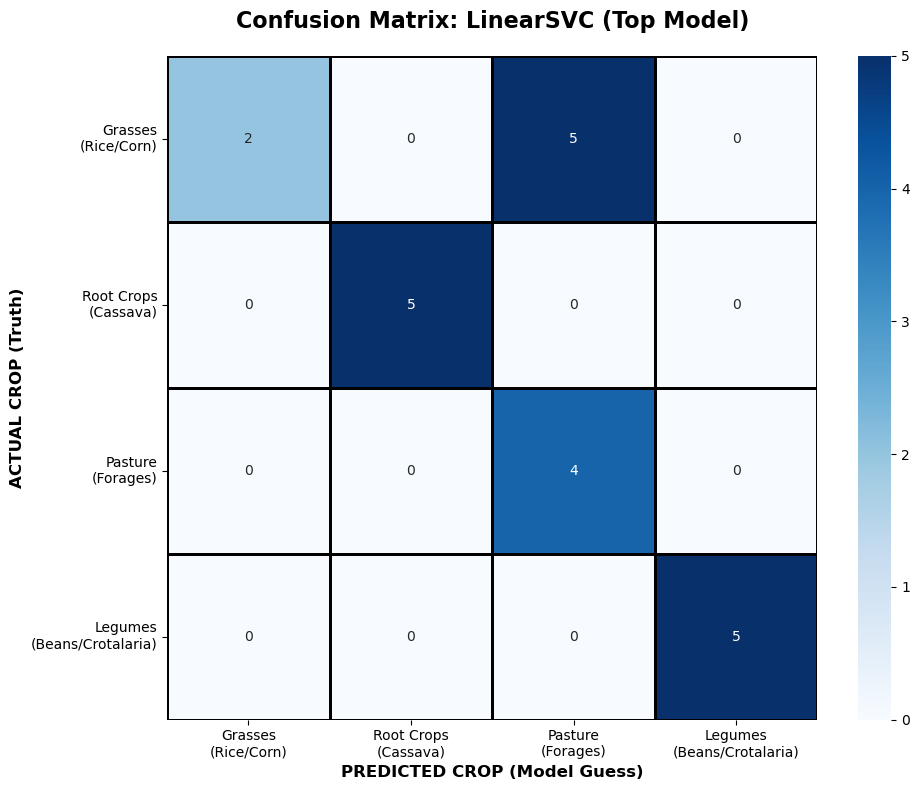

In [40]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. TEXT CONFUSION MATRICES (TOP 3 MODELS)
# ==========================================
# Get the names of the top 3 models from the leaderboard
top_3_model_names = models.head(3).index.tolist()

print("\n=== 🎯 CONFUSION MATRICES FOR TOP 3 MODELS ===")

for name in top_3_model_names:
    # Extract the actual trained model pipeline from LazyPredict's secret dictionary
    fitted_model = clf.models[name]
    
    # Force the model to take the test exam again
    y_pred = fitted_model.predict(X_test)
    
    # Calculate the Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\n🏆 Model: {name}")
    print(cm)

# ==========================================
# 2. BEAUTIFUL HEATMAP FOR THE #1 MODEL
# ==========================================
# Grab the #1 overall model
best_model_name = top_3_model_names[0]
best_model = clf.models[best_model_name]
y_pred_best = best_model.predict(X_test)
cm_best = confusion_matrix(y_test, y_pred_best)

# Setup our beautiful labels based on the grouping we did earlier
class_names = [
    'Grasses\n(Rice/Corn)', 
    'Root Crops\n(Cassava)', 
    'Pasture\n(Forages)', 
    'Legumes\n(Beans/Crotalaria)'
]

# Draw the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm_best, 
            annot=True,        # Show the numbers
            fmt='d',           # Format as integers
            cmap='Blues',      # Use a professional blue color scale
            xticklabels=class_names, 
            yticklabels=class_names,
            linewidths=1, 
            linecolor='black')

plt.title(f"Confusion Matrix: {best_model_name} (Top Model)", fontsize=16, fontweight='bold', pad=20)
plt.ylabel('ACTUAL CROP (Truth)', fontsize=12, fontweight='bold')
plt.xlabel('PREDICTED CROP (Model Guess)', fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()